# Levenshtein Distance (Fuzzy String Matching)
This notebook visualizes the dynamic programming matrix used to calculate the edit distance between two strings.
This algorithm is utilized in the Acuity backend to match extracted business names against the official BPLO registry.



In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def levenshtein_matrix(s1, s2):
    s1 = s1.lower()
    s2 = s2.lower()
    rows = len(s1) + 1
    cols = len(s2) + 1
    distance = [[0 for _ in range(cols)] for _ in range(rows)]
    
    for i in range(1, rows):
        distance[i][0] = i
    for k in range(1, cols):
        distance[0][k] = k
        
    for col in range(1, cols):
        for row in range(1, rows):
            cost = 0 if s1[row-1] == s2[col-1] else 1
            distance[row][col] = min(
                distance[row-1][col] + 1,      # Deletion
                distance[row][col-1] + 1,      # Insertion
                distance[row-1][col-1] + cost  # Substitution
            )
    return distance

# Define our strings
extracted_name = "Ace Laundry Shop"
bplo_name = "EC Laundry Shop"

# Generate Matrix
matrix = levenshtein_matrix(extracted_name, bplo_name)

# Print raw matrix
print(f"Strings: '{extracted_name}' vs '{bplo_name}'\n")
print("Dynamic Programming Matrix:")
for row in matrix:
    print(row)



Strings: 'Ace Laundry Shop' vs 'EC Laundry Shop'

Dynamic Programming Matrix:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
[1, 1, 2, 3, 4, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
[2, 2, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
[3, 2, 2, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
[4, 3, 3, 2, 3, 4, 5, 6, 7, 8, 9, 9, 10, 11, 12, 13]
[5, 4, 4, 3, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
[6, 5, 5, 4, 3, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
[7, 6, 6, 5, 4, 3, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
[8, 7, 7, 6, 5, 4, 3, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[9, 8, 8, 7, 6, 5, 4, 3, 2, 3, 4, 5, 6, 7, 8, 9]
[10, 9, 9, 8, 7, 6, 5, 4, 3, 2, 3, 4, 5, 6, 7, 8]
[11, 10, 10, 9, 8, 7, 6, 5, 4, 3, 2, 3, 4, 5, 6, 7]
[12, 11, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 3, 4, 5, 6]
[13, 12, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 3, 4, 5]
[14, 13, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 3, 4]
[15, 14, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 3]
[16, 15, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2]


### Matrix Visualization Heatmap
The following cell plots the dynamic programming matrix as a color-coded heatmap.
Darker colors represent lower edit distances (closer match), while brighter colors represent higher cumulative edit penalties.



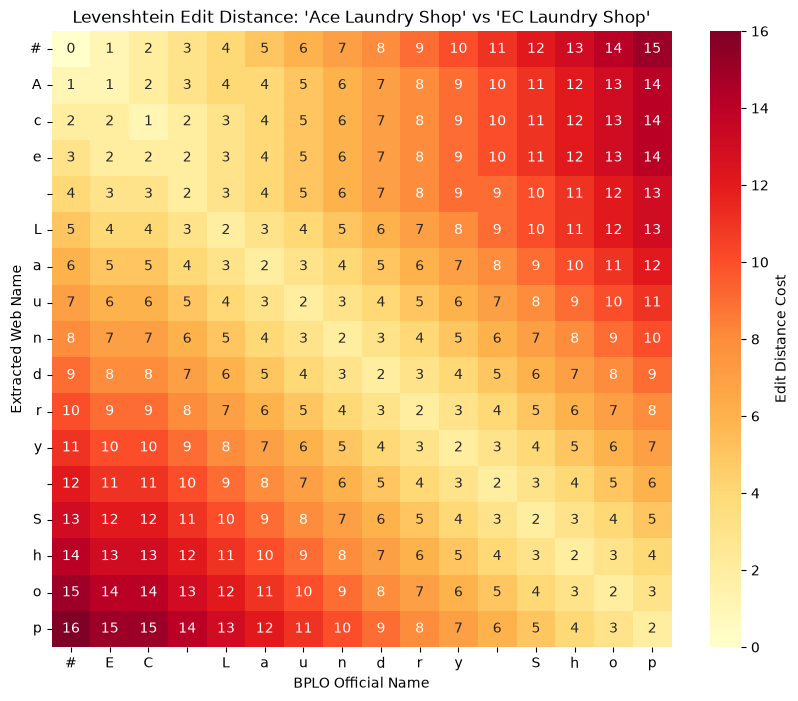

Final Edit Distance: 2
Max Length: 16
Final Similarity Score: 87.50%


In [2]:
# Plotting the Heatmap
plt.figure(figsize=(10, 8))
ax = sns.heatmap(matrix, annot=True, fmt="d", cmap="YlOrRd", cbar_kws={'label': 'Edit Distance Cost'})

# Set Labels
ax.set_xticklabels(['#'] + list(bplo_name))
ax.set_yticklabels(['#'] + list(extracted_name), rotation=0)
plt.title(f"Levenshtein Edit Distance: '{extracted_name}' vs '{bplo_name}'")
plt.xlabel("BPLO Official Name")
plt.ylabel("Extracted Web Name")

plt.show()

# Final Calculation
max_len = max(len(extracted_name), len(bplo_name))
final_edits = matrix[-1][-1]
score = 1.0 - (final_edits / max_len)
print(f"Final Edit Distance: {final_edits}")
print(f"Max Length: {max_len}")
print(f"Final Similarity Score: {score * 100:.2f}%")

